# Proyecto 02: Encontrando Estructuras

## 0. Código y Funciones Auxiliares

In [1]:
# Import de librerías para la realización del proyecto

from pathlib import Path
from itertools import product
from functools import partial
from typing import Callable, Literal

import cv2
import numpy as np
import matplotlib.pyplot as plt

### 0.1 Carga de Imágenes

In [2]:
def load_images_dataset():
    """
    Función para cargar/leer las imágenes del dataset del proyecto. 
    Se cargan usando OpenCV y convertidas al formato RGB.

    Devuelve dos listas, una con las imágenes cargadas y otra 
    con los nombres de las imágenes.
    """

    base_path = Path("./dataset")
    images = []
    filenames =  []
    for path in base_path.iterdir():
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        images.append(image)
        filenames.append(path.name[-5])
    return images, filenames

In [3]:
Path("./results").mkdir(exist_ok=True)
images, filenames = load_images_dataset()

### 0.2 Filtros

Las implementaciones son lentas comparadas con las de CV2, debido a que los ciclos for en Python son lentos en comparación con hacerlos en Cpp o en algún otro lenguaje de bajo nivel. Aunque la implementación llega a lo mismos resultados que con `cv2.filter2D(image, -1, filter, borderType=0)`, lo realiza de forma lenta.

In [4]:
def apply_convolution(
        image: np.ndarray,
        filter: np.ndarray, 
        fill_value: float = 0,
    ) -> np.ndarray:
    """
    Función para aplicar un filtro o kernel 
    a una imagen. El filtro no es rotado 
    180° para hacer coincidir esta función 
    con la implementación de CV2 filter2D. 

    Aplica un padding constante, por defecto 
    igual a 0, esto siguiendo el comportamiento 
    normal en las redes neuronales.

    Devuelve el resultado de aplicar el filtro 
    a la imagen.
    """

    image = image.astype(int)

    padding = (filter.shape[0]-1)//2
    padding_image = np.pad(
        image, 
        {0: padding, 1: padding}, 
        constant_values = fill_value,
    )

    if len(image.shape) == 3:
        filter = filter[:, :, None]

    conv_image = np.zeros_like(image)
    size_height, size_width = image.shape[:2]

    for (i_height, j_width) in product(range(padding, size_height+padding), range(padding, size_width+padding)):
        image_values = padding_image[i_height-padding: i_height+padding+1, j_width-padding: j_width+padding+1]
        conv_image[i_height-padding, j_width-padding] = (image_values*filter).sum(axis=(0, 1))

    return conv_image

In [5]:
def apply_filter_decorator(function_filer: Callable[[], np.ndarray]):
    """
    Decorador para aplicar una filtro específico a 
    una imagen, donde el resultado del filtrado 
    se convierte a una imagen válida para CV2. 
    """

    def apply_filter(
            image: np.ndarray, 
            fill_value: float = 0,
        ) -> np.ndarray:

        conv_image = apply_convolution(image, function_filer(), fill_value)
        return conv_image.round().clip(0, 255).astype(np.uint8)

    return apply_filter

In [6]:
PREWITT_FILTER_HOR = np.array([
    [-1,  0,  1],
    [-1,  0,  1],
    [-1,  0,  1],
])

PREWITT_FILTER_VER = np.rot90(PREWITT_FILTER_HOR)

@apply_filter_decorator
def prewitt_filter_horizontal() -> np.ndarray:
    return PREWITT_FILTER_HOR

@apply_filter_decorator
def prewitt_filter_vertical() -> np.ndarray:
    return PREWITT_FILTER_VER

In [7]:
SOBEL_FILTER_HOR = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1],
])

SOBEL_FILTER_VER = np.rot90(SOBEL_FILTER_HOR) 

@apply_filter_decorator
def sobel_filter_horizontal() -> np.ndarray:
    return SOBEL_FILTER_HOR

@apply_filter_decorator
def sobel_filter_vertical() -> np.ndarray:
    return SOBEL_FILTER_VER

In [8]:
LAPLACIAN_FILTER_1 = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0],
])

@apply_filter_decorator
def laplacian_filter_1() -> np.ndarray:
    return LAPLACIAN_FILTER_1

LAPLACIAN_FILTER_2 = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1],
])

@apply_filter_decorator
def laplacian_filter_2() -> np.ndarray:
    return LAPLACIAN_FILTER_2

In [9]:
LAPLACIAN_GAUSSIAN_FILTER = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 2, 1, 0],
    [1, 2, -16, 2, 1],
    [0, 1, 2, 1, 0],
    [0, 0, 1, 0, 0],
])

@apply_filter_decorator
def laplacian_gaussian_filter() -> np.ndarray:
    return LAPLACIAN_GAUSSIAN_FILTER

In [10]:
def canny_filter(
        image: np.ndarray,
        lower_bound: int,
        upper_bound: int,
    ) -> np.ndarray:

    return cv2.Canny(image, lower_bound, upper_bound)

In [11]:
def apply_filter_base_cv2(
        filter: np.ndarray
    ) -> Callable[[np.ndarray], np.ndarray]:
    """
    Función wrapper para aplicar un filtro 
    a una imagen usando las funciones de CV2. 

    Se aplica un padding constante para que el output 
    image size sea igual al input.

    Devuelve la función para aplicar el filer 
    a la imagen.
    """

    def apply_filter_cv2(image: np.ndarray) -> np.ndarray:
        return cv2.filter2D(image, -1, filter, borderType=0)
    
    return apply_filter_cv2

prewitt_filter_horizontal_cv2 = apply_filter_base_cv2(PREWITT_FILTER_HOR)
prewitt_filter_vertical_cv2 = apply_filter_base_cv2(PREWITT_FILTER_VER)
sobel_filter_horizontal_cv2 = apply_filter_base_cv2(SOBEL_FILTER_HOR)
sobel_filter_vertical_cv2 = apply_filter_base_cv2(SOBEL_FILTER_VER)
laplacian_filter_1_cv2 = apply_filter_base_cv2(LAPLACIAN_FILTER_1)
laplacian_filter_2_cv2 = apply_filter_base_cv2(LAPLACIAN_FILTER_2)
laplacian_gaussian_filter_cv2 = apply_filter_base_cv2(LAPLACIAN_GAUSSIAN_FILTER)

In [12]:
class TypeFilters:
    all_names = ["prewitt", "sobel", "laplacian_1", "laplacian_2", "laplacian_gaussian"]

    prewitt = [PREWITT_FILTER_HOR, PREWITT_FILTER_VER]
    sobel = [SOBEL_FILTER_HOR, SOBEL_FILTER_VER]
    laplacian_1 = [LAPLACIAN_FILTER_1, LAPLACIAN_FILTER_1]
    laplacian_2 = [LAPLACIAN_FILTER_2, LAPLACIAN_FILTER_2]
    laplacian_gaussian = [LAPLACIAN_GAUSSIAN_FILTER, LAPLACIAN_GAUSSIAN_FILTER]

    function_prewitt = [prewitt_filter_horizontal_cv2, prewitt_filter_vertical_cv2]
    function_sobel = [sobel_filter_horizontal_cv2, sobel_filter_vertical_cv2]
    function_laplacian_1 = [laplacian_filter_1_cv2]
    function_laplacian_2 = [laplacian_filter_2_cv2]
    function_laplacian_gaussian = [laplacian_gaussian_filter_cv2]

    name_prewitt = "Prewitt"
    name_sobel = "Sobel"
    name_laplacian_1 = "Laplace 1"
    name_laplacian_2 = "Laplace 2"
    name_laplacian_gaussian = "Laplaciano de Gaussiana"

    @classmethod
    def get_filter(cls, type_filter: str) -> tuple[np.ndarray, np.ndarray]:
        return vars(TypeFilters)[type_filter]
    
    @classmethod
    def get_functions(cls, type_filter: str) -> tuple[Callable[[np.ndarray], np.ndarray], Callable[[np.ndarray], np.ndarray]]:
        return vars(TypeFilters)["function_"+type_filter]
    
    @classmethod
    def get_name(cls, type_filter: str) -> str:
        return vars(TypeFilters)["name_"+type_filter]

### 0.3 Visualizar Imágenes

In [13]:
def save_plot(
        create_plot: Callable[[np.ndarray, str], tuple[plt.Figure, str | None]]
    ) -> Callable:
    """
    Función para guardar un plot diseñado o 
    creado. Se espera que la función decorada 
    devuelva el objeto Figure y el nombre de 
    la figura.

    Devuelve el plot creado.
    """

    def saver(image: np.ndarray, *args, **kwargs) -> plt.Figure:
        fig, fig_name = create_plot(image, *args, **kwargs)
        if fig_name: fig.savefig(f"./results/{fig_name}.jpg", dpi=300, bbox_inches="tight")
        return fig
    
    return saver

In [14]:
@save_plot
def visual_describe_plot(image: np.ndarray, filename: str) -> tuple[plt.Figure, str]:
    """
    Función para describir visualmente una imagen 
    mostrando su versión original y a escala de grises.

    Devuelve el plot generado.
    """

    fig, axes = plt.subplots(
        ncols = 2,
        subplot_kw = {
            "yticks": [],
            "xticks": [],
        },
        figsize = (8, 3),
    )

    axes[0].imshow(image)
    axes[1].imshow(cv2.cvtColor(image, cv2.COLOR_RGB2GRAY), "gray")

    fig.suptitle(f"Imagen Original y a Escala de Grises de la Imagen {filename.replace("_", " ")}")

    return fig, f"describe_{filename}"

In [15]:
@save_plot
def orientation_borders_plot(
        image: np.ndarray, 
        filename: str, 
        type_filter: Literal["prewitt", "sobel", "laplacian_1", "laplacian_2", "laplacian_gaussian"],
    ) -> tuple[plt.Figure, str]:
    """
    Función para mostrar la orientación 
    de los bordes presentes en una 
    imagen. Se puede escoger el tipo de 
    filtro que se empleará para calcular 
    los gradientes direccionales.

    Devuelve el plot diseñado.
    """
    filter_horizontal, filter_vertical = TypeFilters.get_filter(type_filter)

    gradient_x = cv2.filter2D(image.astype(float), -1, filter_horizontal, borderType=0)
    gradient_y = cv2.filter2D(image.astype(float), -1, filter_vertical, borderType=0)
    magnitude = np.sqrt(gradient_x**2+gradient_y**2+1e-32)
    gradient_x /= magnitude
    gradient_y /= magnitude

    meshgrid_x = np.linspace(0, image.shape[1]-1, image.shape[1], dtype=int)
    meshgrid_y = np.linspace(image.shape[0]-1, 0, image.shape[0], dtype=int)
    meshgrid_x, meshgrid_y = np.meshgrid(meshgrid_x, meshgrid_y)

    fig, axes = plt.subplots(
        subplot_kw = {
            "yticks": [],
            "xticks": [],
        },
        figsize = (5, 4),
    )

    axes.quiver(meshgrid_x, meshgrid_y, gradient_x, gradient_y)

    fig.suptitle(f"Orientación de los bordes de la Imagen {filename.replace("_", " ")}")

    return fig, f"orientation_{filename}"

In [16]:
@save_plot
def compare_filter_plot(
        image: np.ndarray, 
        filename: str, 
        type_filter: Literal["prewitt", "sobel", "laplacian_1", "laplacian_2", "laplacian_gaussian"] | Callable[[np.ndarray], np.ndarray],
        color: Literal["gray", None] = None,
    ) -> tuple[plt.Figure, str]:
    """
    Función para comparar la variante 
    vertical y horizontal de un cierto 
    filtro en una imagen.

    Devuelve el plot diseñado. 
    """

    if color:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    if isinstance(type_filter, str):
        fig, axes = plt.subplots(
            ncols = 1,
            subplot_kw = {
                "yticks": [],
                "xticks": [],
            },
            figsize = (8, 2.5),
        )

        function_filters = TypeFilters.get_functions(type_filter)

        filtered_image = sum([function_filter(image).astype(int) for function_filter in function_filters])
        axes.imshow(filtered_image.clip(0, 255), color)

        fig.suptitle(f"Comparación del Filtro {TypeFilters.get_name(type_filter)} de la Imagen {filename.replace("_", " ")}")
        
        return fig, f"filter_{type_filter}_{filename}"
    
    else:
        fig, axes = plt.subplots(
            ncols = 1,
            subplot_kw = {
                "yticks": [],
                "xticks": [],
            },
            figsize = (8, 2.5),
        )

        axes.imshow(type_filter(image), color)

        fig.suptitle(f"Comparación del Filtro Canny de la Imagen {filename.replace("_", " ")}")
        
        return fig, f"filter_canny_{filename}"

## 1. Imagen 1

In [17]:
img_1 = images[0]
file_1 = filenames[0]

### 1.1 Sin Suavizar

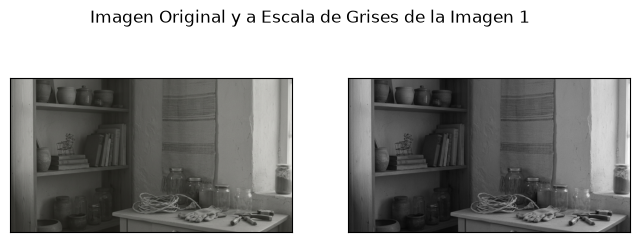

In [18]:
visual_describe_plot(img_1, file_1);

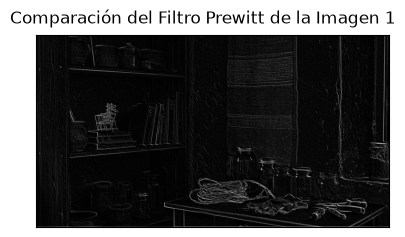

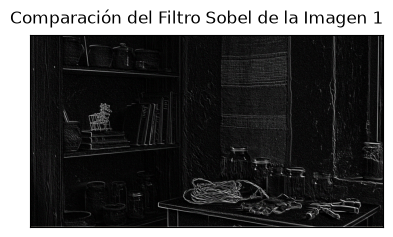

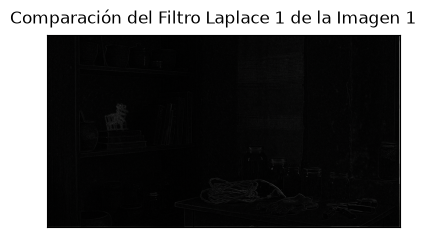

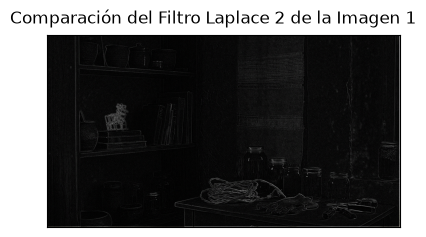

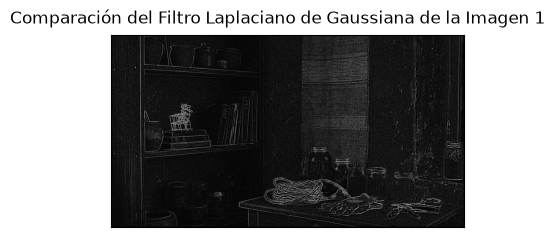

In [19]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_1, file_1, filter_name);

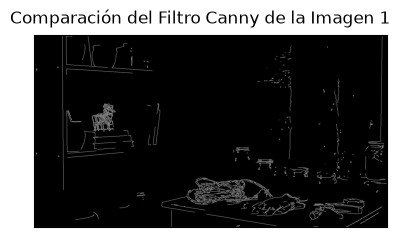

In [20]:
type_filter = partial(canny_filter, lower_bound=110, upper_bound=190)
compare_filter_plot(img_1, file_1, type_filter, "gray");

### 1.2 Suavizado con Kernel $3\times3$

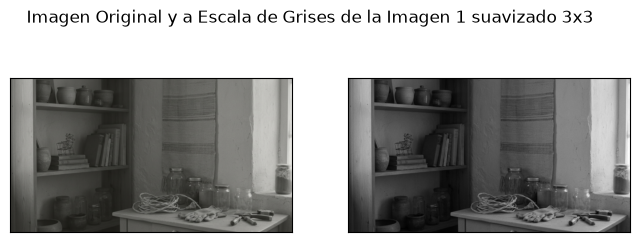

In [21]:
img_1_suavizado_3x3 = cv2.GaussianBlur(img_1, (3,3), 0)
file_1_suavizado_3x3 = file_1+"_suavizado_3x3"

visual_describe_plot(img_1_suavizado_3x3, file_1_suavizado_3x3);

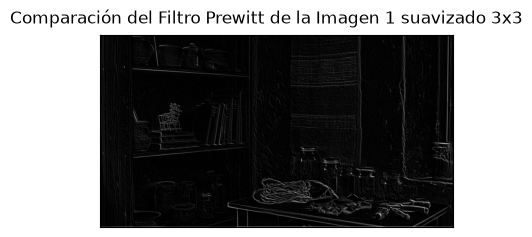

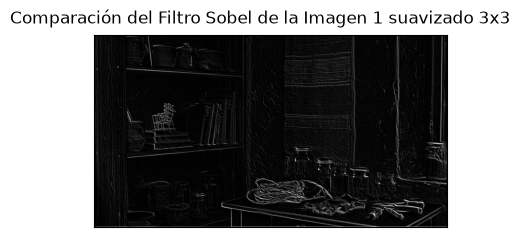

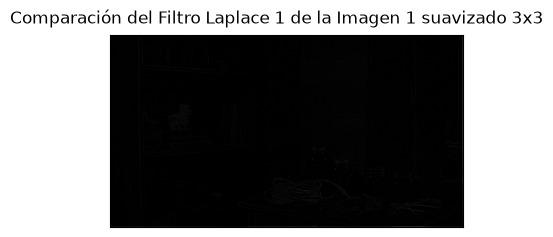

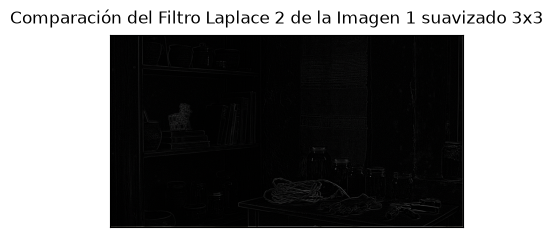

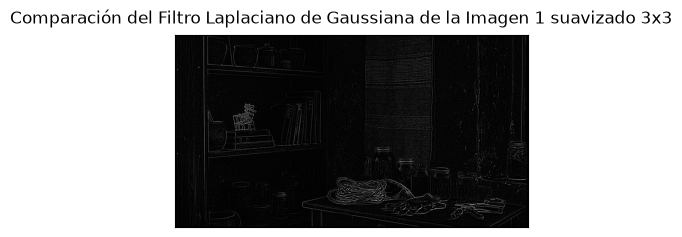

In [22]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_1_suavizado_3x3, file_1_suavizado_3x3, filter_name);

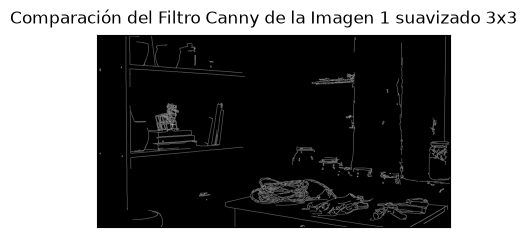

In [23]:
type_filter = partial(canny_filter, lower_bound=35, upper_bound=140)
compare_filter_plot(img_1_suavizado_3x3, file_1_suavizado_3x3, type_filter, "gray");

### 1.3 Suavizado con Kernel $7\times7$

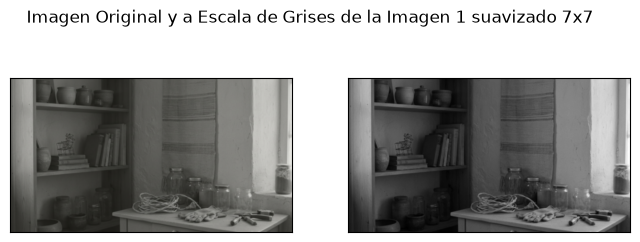

In [24]:
img_1_suavizado_7x7 = cv2.GaussianBlur(img_1, (7,7), 0)
file_1_suavizado_7x7 = file_1+"_suavizado_7x7"

visual_describe_plot(img_1_suavizado_7x7, file_1_suavizado_7x7);

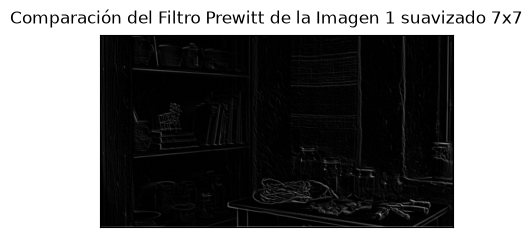

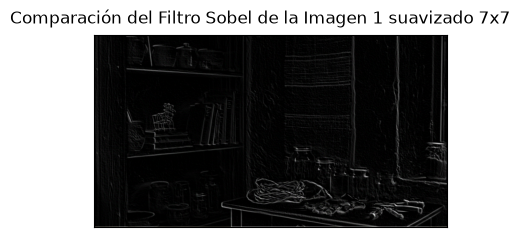

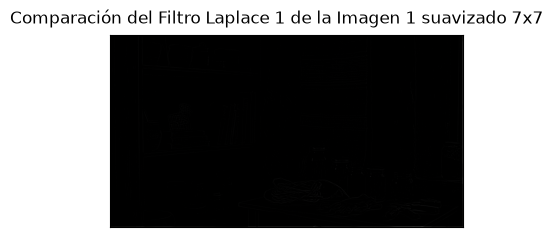

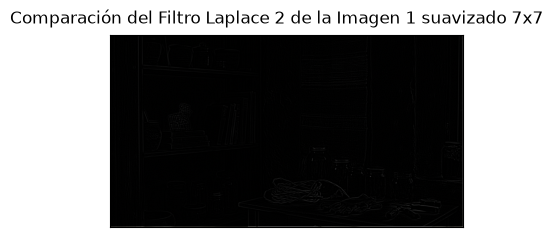

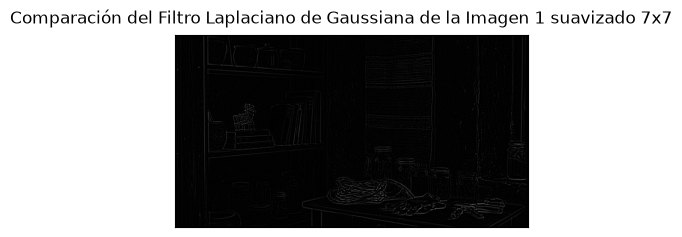

In [25]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_1_suavizado_7x7, file_1_suavizado_7x7, filter_name);

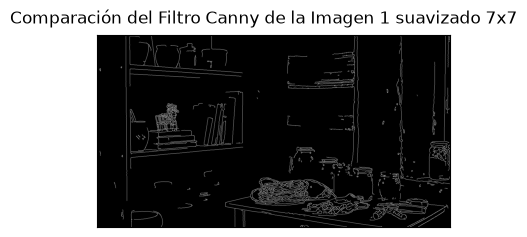

In [26]:
type_filter = partial(canny_filter, lower_bound=25, upper_bound=50)
compare_filter_plot(img_1_suavizado_7x7, file_1_suavizado_7x7, type_filter, "gray");

## 2. Imagen 2

In [27]:
img_2 = images[1]
file_2 = filenames[1]

### 2.1 Sin Suavizar

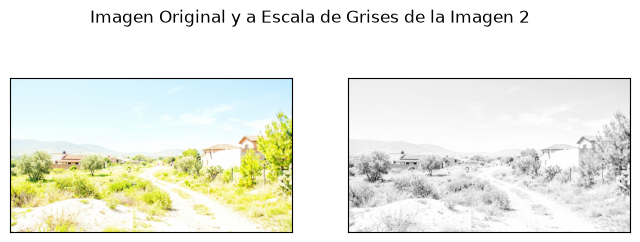

In [28]:
visual_describe_plot(img_2, file_2);

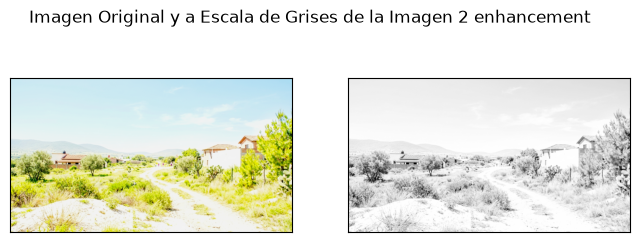

In [29]:
gain = 1.15
bias = -50
gamma = 0
ench_img_2 = cv2.addWeighted(img_2, gain, np.zeros_like(img_2, img_2.dtype), gamma, bias)

visual_describe_plot(ench_img_2, file_2+"_enhancement");

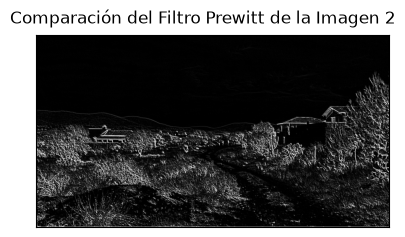

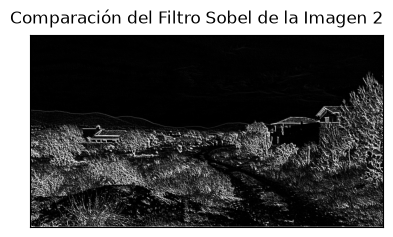

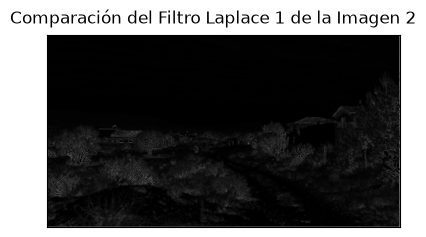

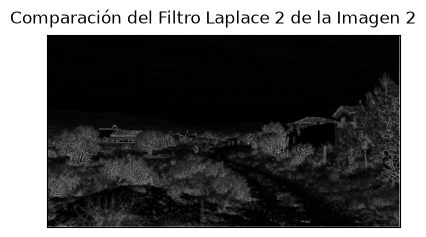

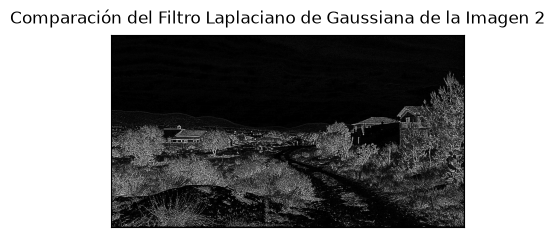

In [30]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(ench_img_2, file_2, filter_name, "gray");

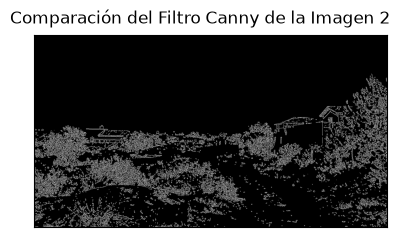

In [31]:
type_filter = partial(canny_filter, lower_bound=140, upper_bound=200)
compare_filter_plot(ench_img_2, file_2, type_filter, "gray");

### 2.2 Suavizado con Kernel $3\times3$

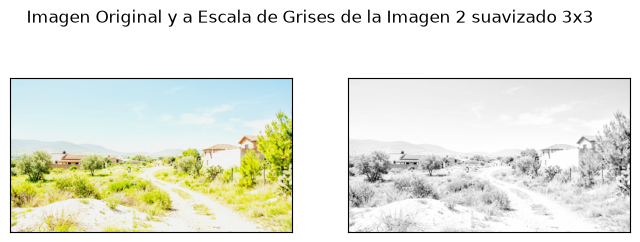

In [32]:
img_2_suavizado_3x3 = cv2.GaussianBlur(ench_img_2, (3,3), 0)
file_2_suavizado_3x3 = file_2+"_suavizado_3x3"

visual_describe_plot(img_2_suavizado_3x3, file_2_suavizado_3x3);

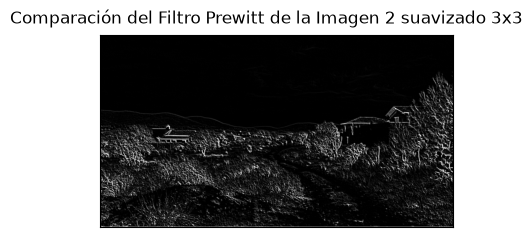

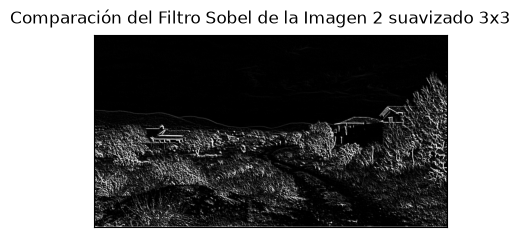

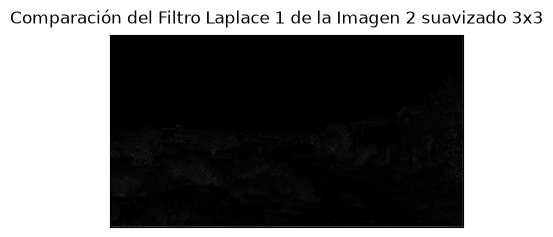

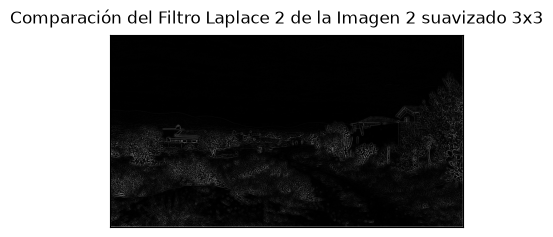

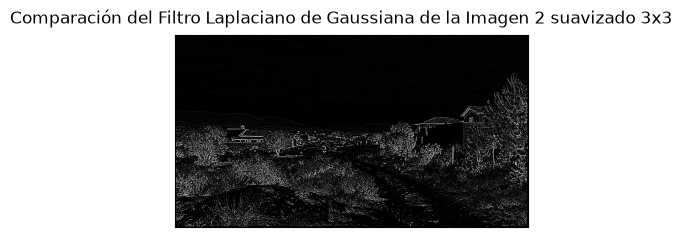

In [33]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_2_suavizado_3x3, file_2_suavizado_3x3, filter_name, "gray");

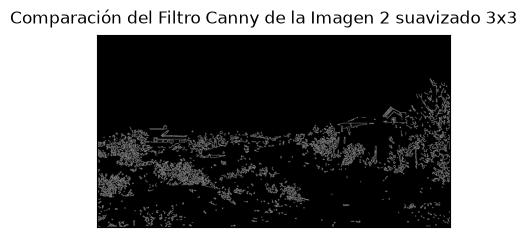

In [34]:
type_filter = partial(canny_filter, lower_bound=140, upper_bound=250)
compare_filter_plot(img_2_suavizado_3x3, file_2_suavizado_3x3, type_filter, "gray");

### 2.3 Suavizado con Kernel $7\times7$

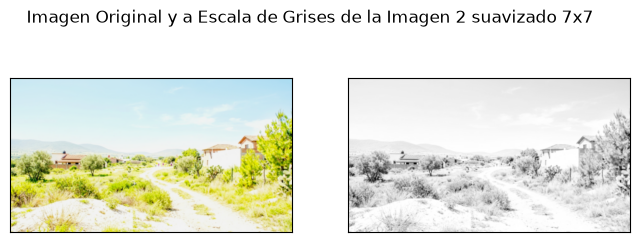

In [35]:
img_2_suavizado_7x7 = cv2.GaussianBlur(ench_img_2, (7,7), 0)
file_2_suavizado_7x7 = file_2+"_suavizado_7x7"

visual_describe_plot(img_2_suavizado_7x7, file_2_suavizado_7x7);

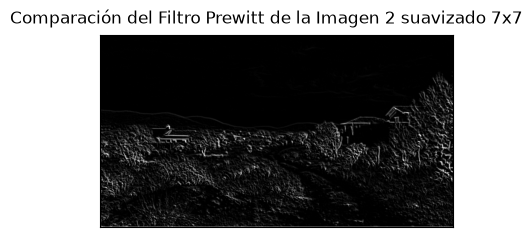

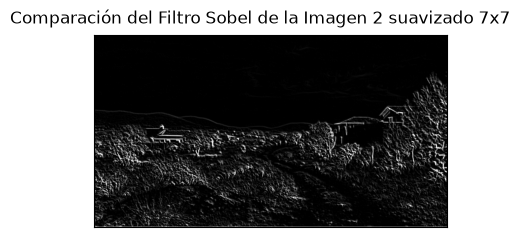

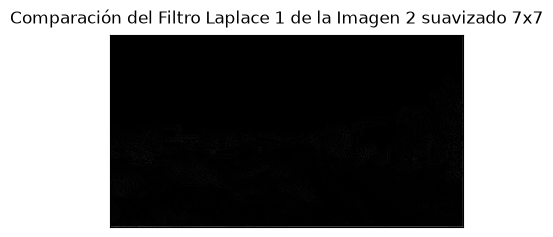

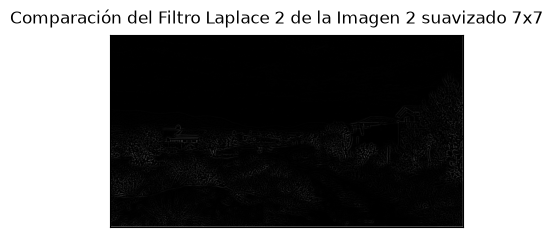

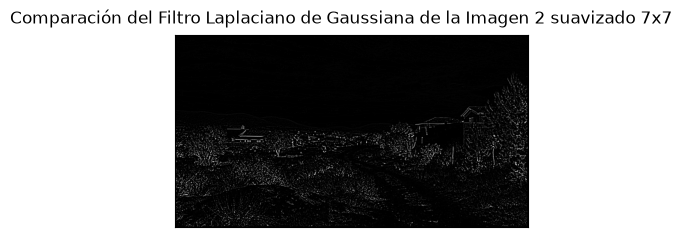

In [36]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_2_suavizado_7x7, file_2_suavizado_7x7, filter_name, "gray");

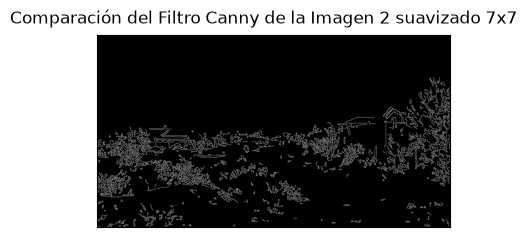

In [37]:
type_filter = partial(canny_filter, lower_bound=50, upper_bound=150)
compare_filter_plot(img_2_suavizado_7x7, file_2_suavizado_7x7, type_filter, "gray");

## 3. Imagen 3

In [38]:
img_3 = images[2]
file_3 = filenames[2]

### 3.1 Sin Suavizar

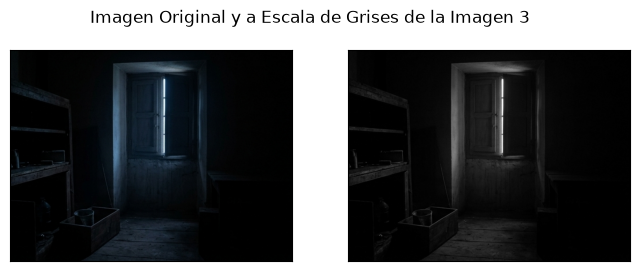

In [39]:
visual_describe_plot(img_3, file_3);

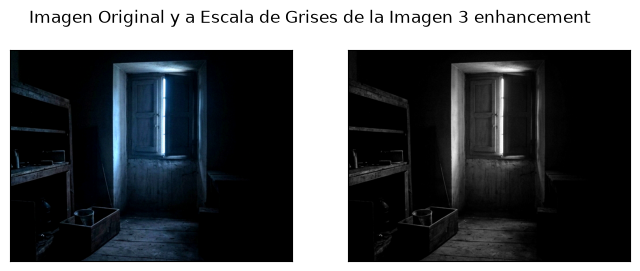

In [40]:
gain = 2
bias = -10
gamma = 0
ench_img_3 = cv2.addWeighted(img_3, gain, np.zeros_like(img_3, img_3.dtype), gamma, bias)

visual_describe_plot(ench_img_3, file_3+"_enhancement");

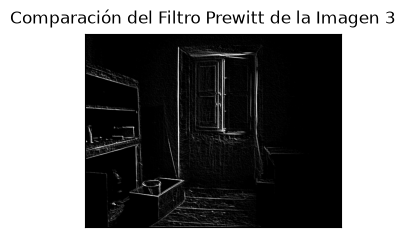

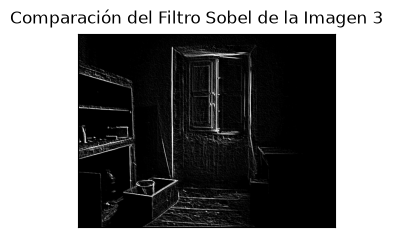

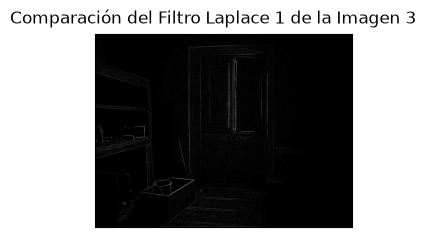

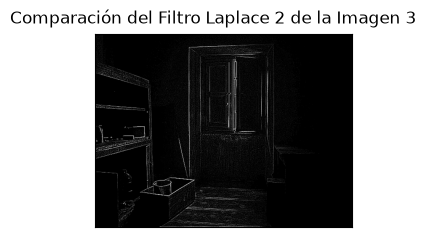

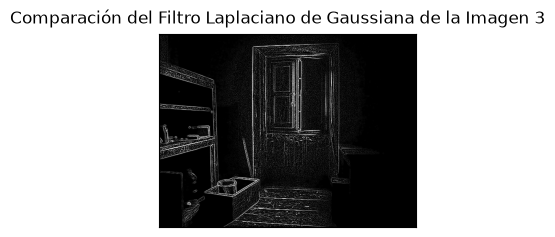

In [41]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(ench_img_3, file_3, filter_name, "gray");

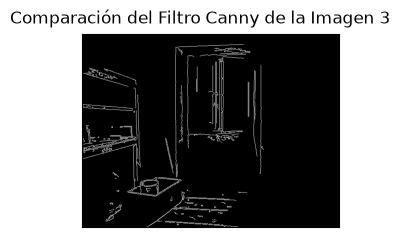

In [42]:
type_filter = partial(canny_filter, lower_bound=90, upper_bound=180)
compare_filter_plot(ench_img_3, file_3, type_filter, "gray");

### 3.2 Suavizado con Kernel $3\times3$

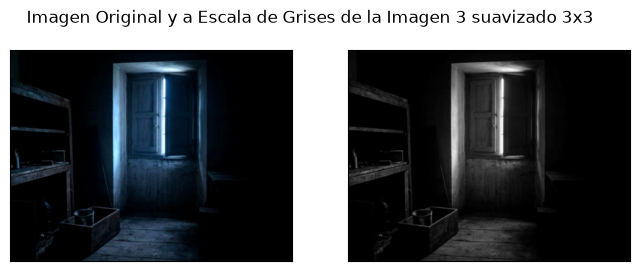

In [43]:
img_3_suavizado_3x3 = cv2.GaussianBlur(ench_img_3, (3,3), 0)
file_3_suavizado_3x3 = file_3+"_suavizado_3x3"

visual_describe_plot(img_3_suavizado_3x3, file_3_suavizado_3x3);

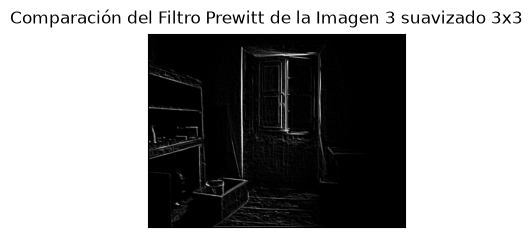

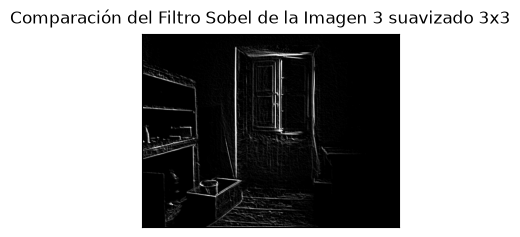

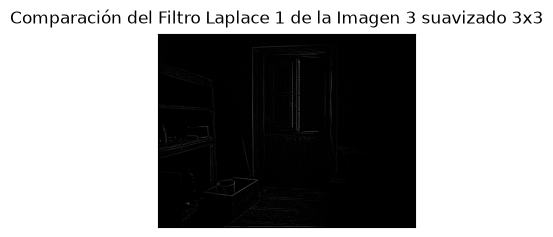

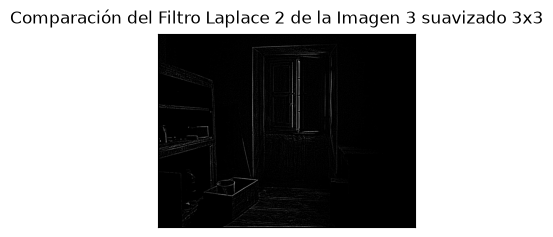

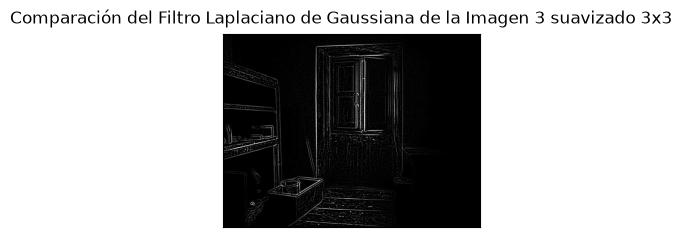

In [44]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_3_suavizado_3x3, file_3_suavizado_3x3, filter_name, "gray");

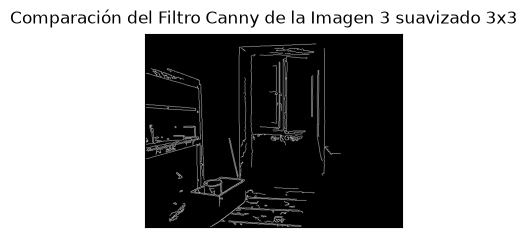

In [45]:
type_filter = partial(canny_filter, lower_bound=40, upper_bound=120)
compare_filter_plot(img_3_suavizado_3x3, file_3_suavizado_3x3, type_filter, "gray");

### 3.3 Suavizado con Kernel $7\times7$

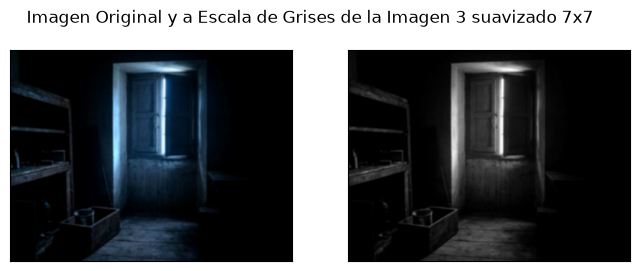

In [46]:
img_3_suavizado_7x7 = cv2.GaussianBlur(ench_img_3, (7,7), 0)
file_3_suavizado_7x7 = file_3+"_suavizado_7x7"

visual_describe_plot(img_3_suavizado_7x7, file_3_suavizado_7x7);

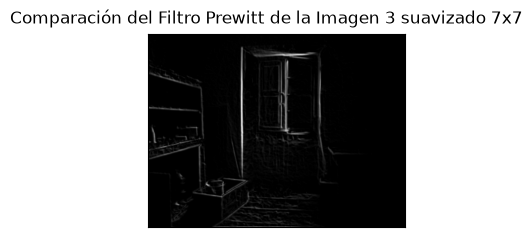

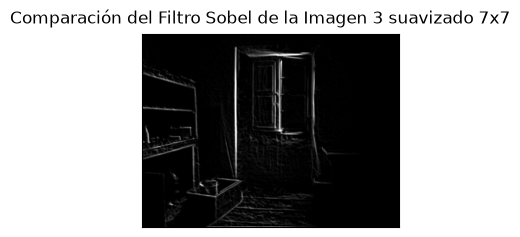

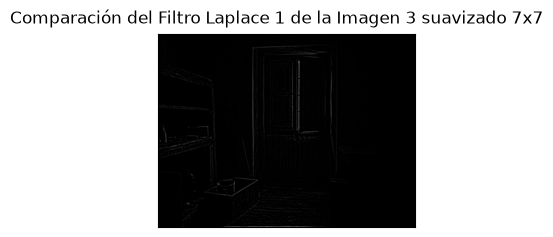

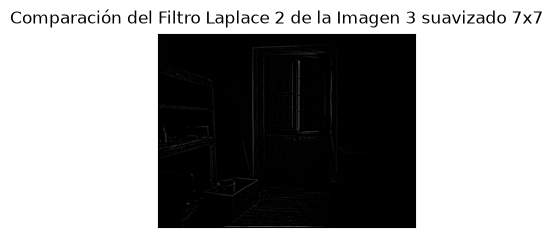

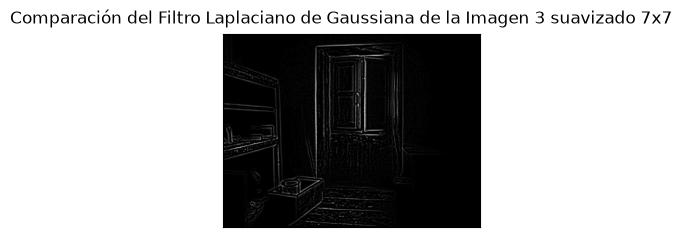

In [47]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_3_suavizado_7x7, file_3_suavizado_7x7, filter_name, "gray");

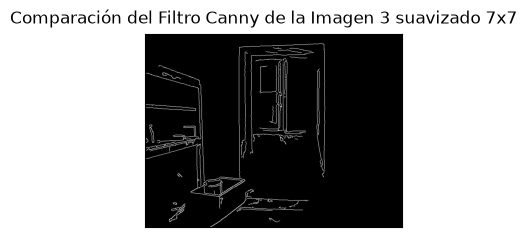

In [48]:
type_filter = partial(canny_filter, lower_bound=15, upper_bound=90)
compare_filter_plot(img_3_suavizado_7x7, file_3_suavizado_7x7, type_filter, "gray");

## 4. Imagen 4

In [49]:
img_4 = images[3]
file_4 = filenames[3]

### 4.1 Sin Suavizar

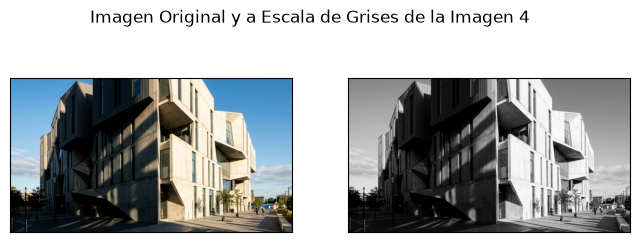

In [50]:
visual_describe_plot(img_4, file_4);

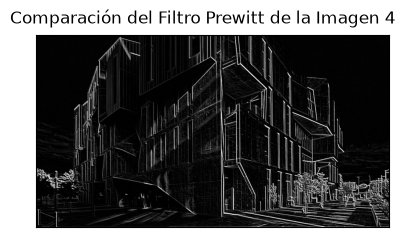

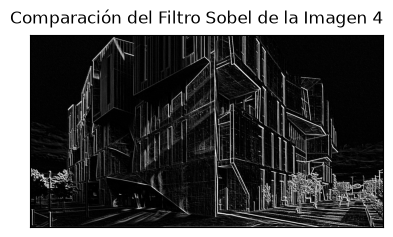

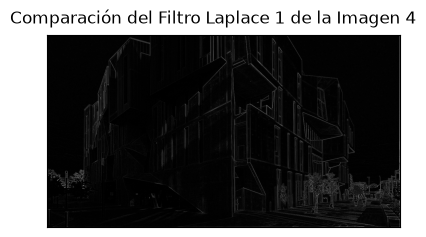

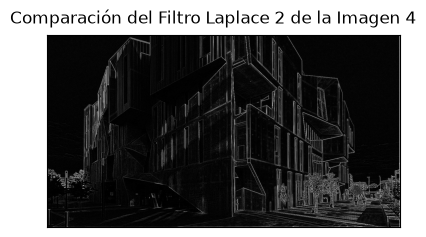

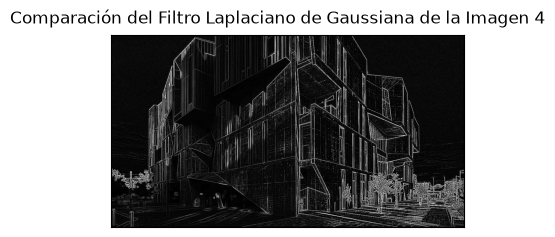

In [51]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_4, file_4, filter_name, "gray");

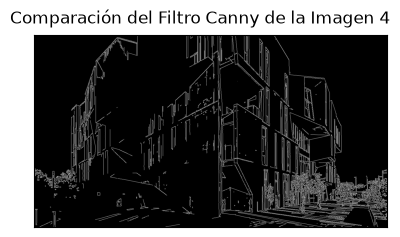

In [52]:
type_filter = partial(canny_filter, lower_bound=120, upper_bound=200)
compare_filter_plot(img_4, file_4, type_filter, "gray");

### 4.2 Suavizado con Kernel $3\times3$

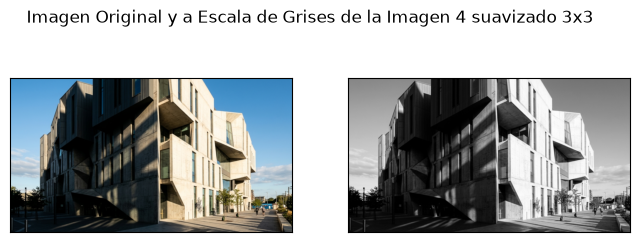

In [53]:
img_4_suavizado_3x3 = cv2.GaussianBlur(img_4, (3,3), 0)
file_4_suavizado_3x3 = file_4+"_suavizado_3x3"

visual_describe_plot(img_4_suavizado_3x3, file_4_suavizado_3x3);

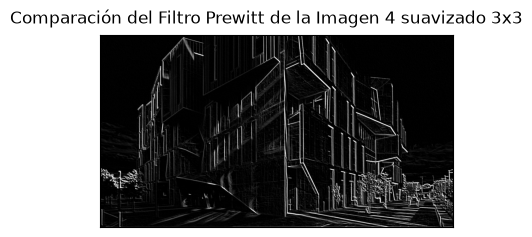

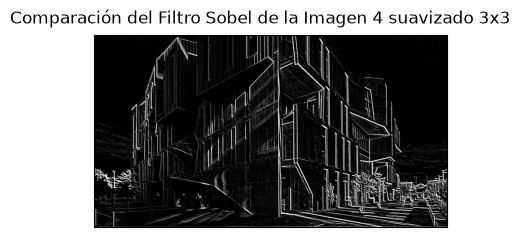

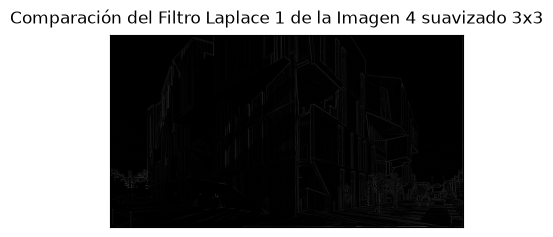

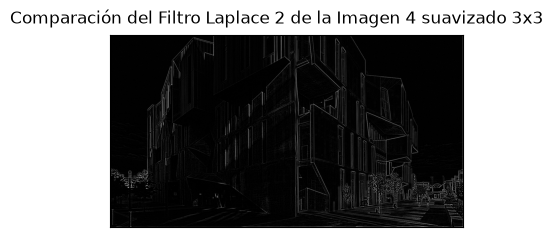

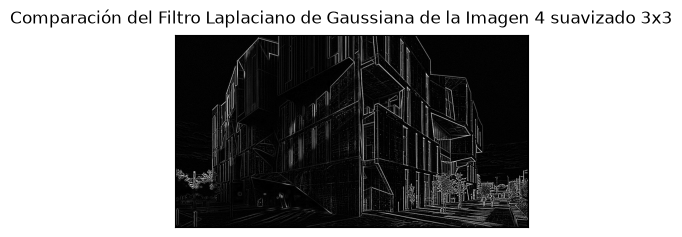

In [54]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_4_suavizado_3x3, file_4_suavizado_3x3, filter_name, "gray");

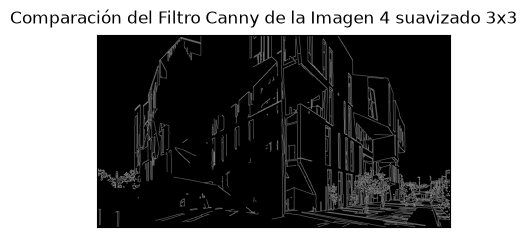

In [55]:
type_filter = partial(canny_filter, lower_bound=90, upper_bound=180)
compare_filter_plot(img_4_suavizado_3x3, file_4_suavizado_3x3, type_filter, "gray");

### 4.3 Suavizado con Kernel $7\times7$

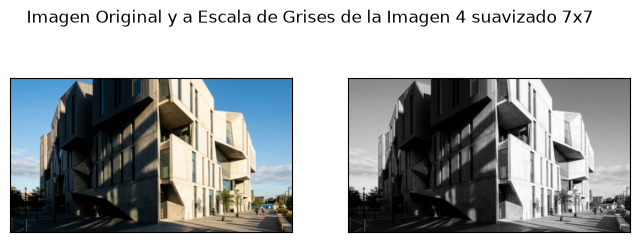

In [56]:
img_4_suavizado_7x7 = cv2.GaussianBlur(img_4, (7,7), 0)
file_4_suavizado_7x7 = file_4+"_suavizado_7x7"

visual_describe_plot(img_4_suavizado_7x7, file_4_suavizado_7x7);

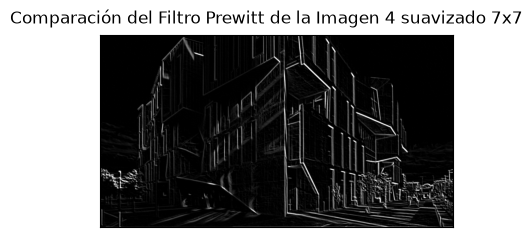

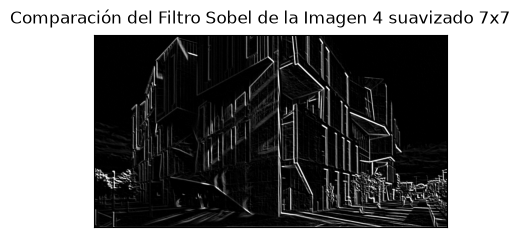

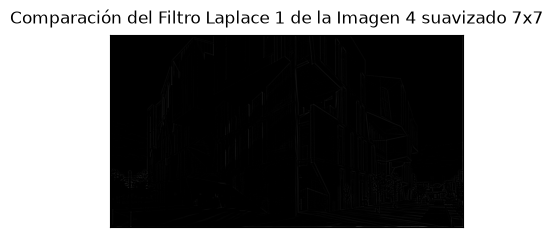

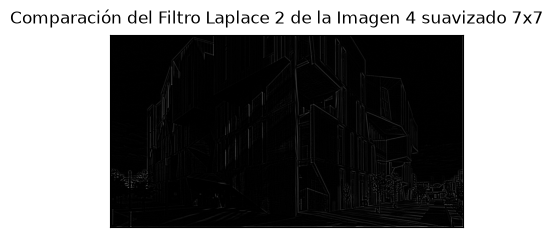

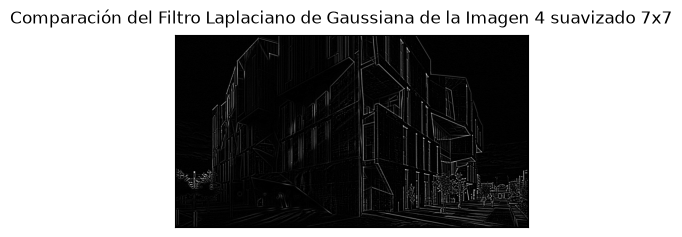

In [57]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_4_suavizado_7x7, file_4_suavizado_7x7, filter_name, "gray");

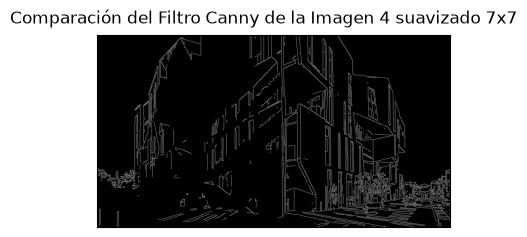

In [58]:
type_filter = partial(canny_filter, lower_bound=80, upper_bound=100)
compare_filter_plot(img_4_suavizado_7x7, file_4_suavizado_7x7, type_filter, "gray");

## 5. Imagen 5

In [59]:
img_5 = images[4]
file_5 = filenames[4]

### 5.1 Sin Suavizar

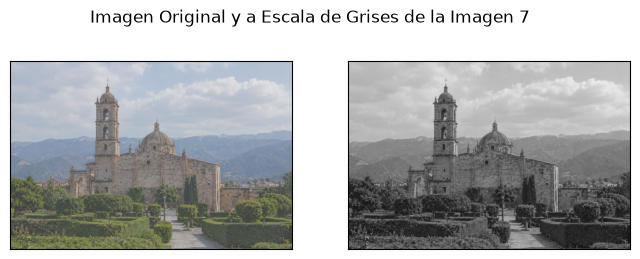

In [60]:
visual_describe_plot(img_5, file_5);

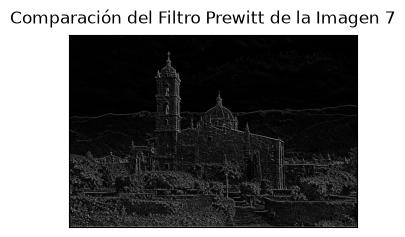

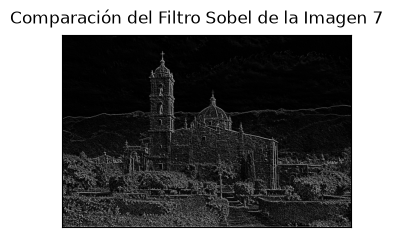

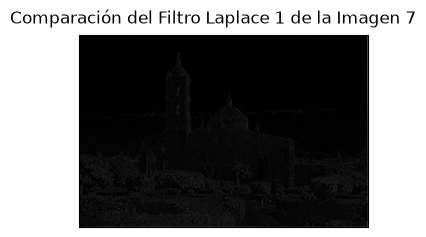

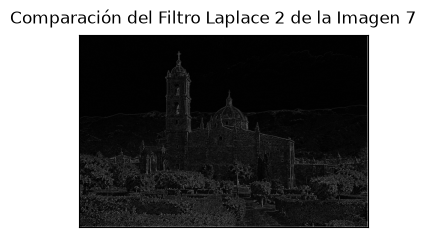

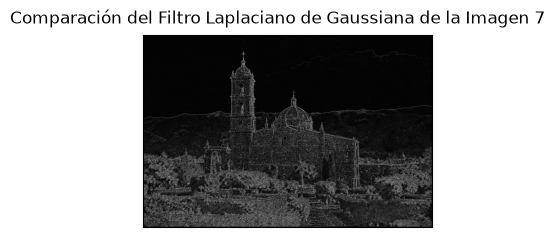

In [61]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_5, file_5, filter_name, "gray");

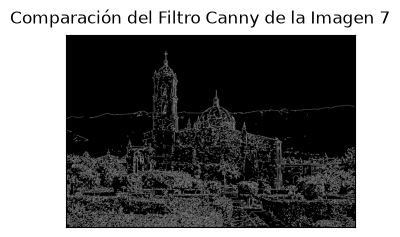

In [62]:
type_filter = partial(canny_filter, lower_bound=90, upper_bound=150)
compare_filter_plot(img_5, file_5, type_filter, "gray");

### 5.2 Suavizado con Kernel $3\times3$

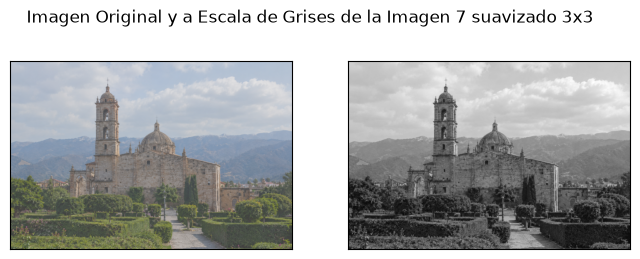

In [63]:
img_5_suavizado_3x3 = cv2.GaussianBlur(img_5, (3,3), 0)
file_5_suavizado_3x3 = file_5+"_suavizado_3x3"

visual_describe_plot(img_5_suavizado_3x3, file_5_suavizado_3x3);

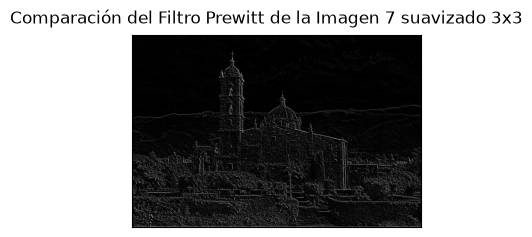

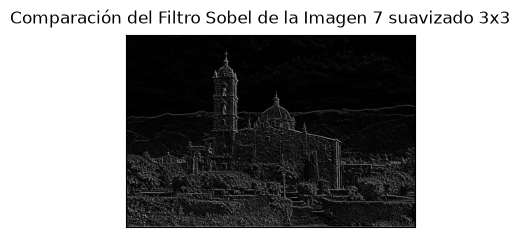

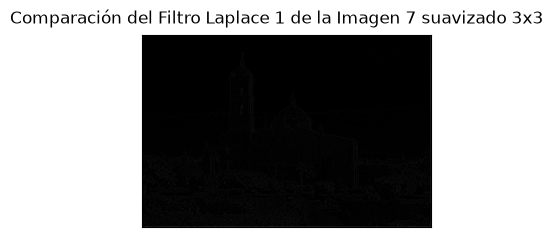

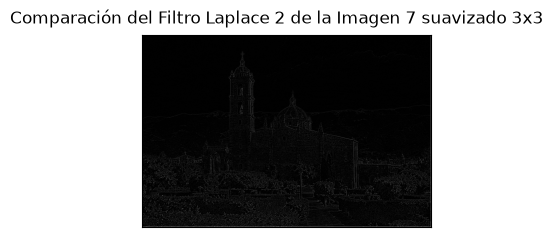

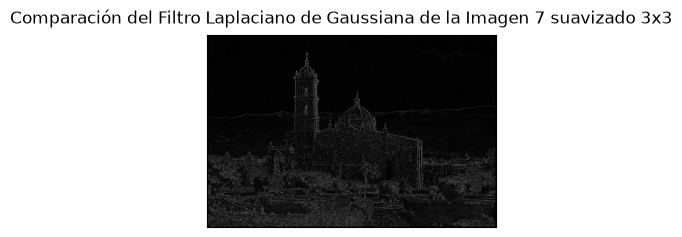

In [64]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_5_suavizado_3x3, file_5_suavizado_3x3, filter_name, "gray");

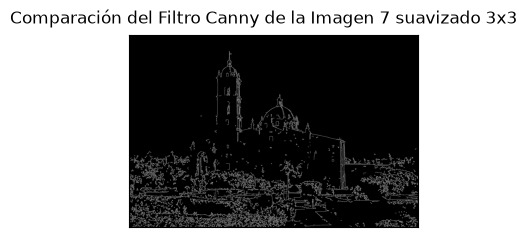

In [65]:
type_filter = partial(canny_filter, lower_bound=90, upper_bound=180)
compare_filter_plot(img_5_suavizado_3x3, file_5_suavizado_3x3, type_filter, "gray");

### 5.3 Suavizado con Kernel $7\times7$

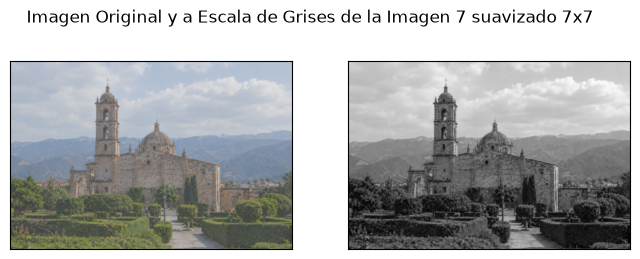

In [66]:
img_5_suavizado_7x7 = cv2.GaussianBlur(img_5, (7,7), 0)
file_5_suavizado_7x7 = file_5+"_suavizado_7x7"

visual_describe_plot(img_5_suavizado_7x7, file_5_suavizado_7x7);

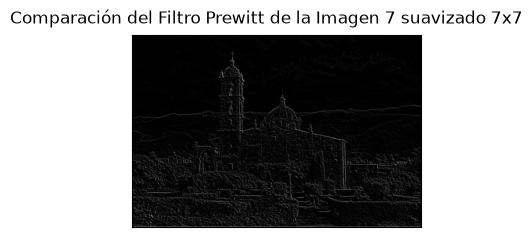

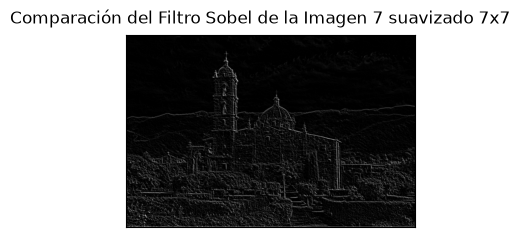

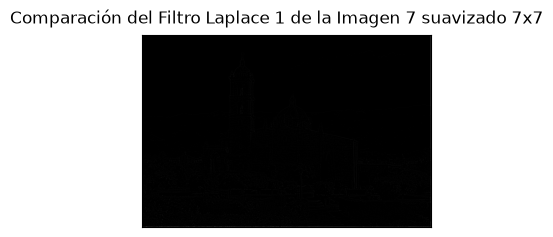

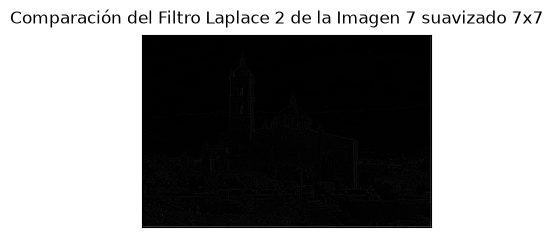

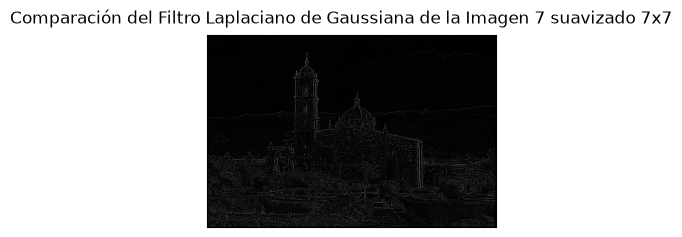

In [67]:
for filter_name in TypeFilters.all_names:
    compare_filter_plot(img_5_suavizado_7x7, file_5_suavizado_7x7, filter_name, "gray");

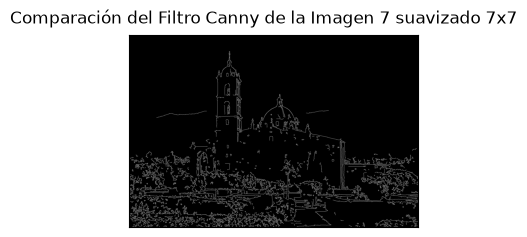

In [68]:
type_filter = partial(canny_filter, lower_bound=50, upper_bound=100)
compare_filter_plot(img_5_suavizado_7x7, file_5_suavizado_7x7, type_filter, "gray");